In [92]:
import sys
from pathlib import Path

# ============================================================
# Rutas fijas del experimento
# El notebook funciona independientemente de la carpeta desde
# donde se inicie Jupyter.
# ============================================================

project_dir = Path("/proj/multipress/users/x_sebja/Exp_32_Jul_cfd")
experiment_dir = project_dir / "13mm_CFD"
data_dir = experiment_dir / "data"
scr_dir = project_dir / "scr"

for required_dir in [project_dir, experiment_dir, data_dir, scr_dir]:
    if not required_dir.exists():
        raise FileNotFoundError(

            f"No se encontró la carpeta requerida:\n{required_dir}"
        )

if str(scr_dir) not in sys.path:
    sys.path.insert(0, str(scr_dir))

print("Project directory:   ", project_dir)
print("Experiment directory:", experiment_dir)
print("Data directory:      ", data_dir)
print("Modules directory:   ", scr_dir)

import os
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.ticker import MaxNLocator, StrMethodFormatter
from scipy.io import loadmat
try:
    from ipywidgets import widgets, interact
    HAS_IPYWIDGETS = True
except ImportError:
    HAS_IPYWIDGETS = False

    class _FallbackSlider:
        def __init__(self, value=0, **kwargs):
            self.value = value

    class _FallbackWidgets:
        IntSlider = _FallbackSlider

    widgets = _FallbackWidgets()

    def interact(**controls):
        def decorator(function):
            values = {name: control.value for name, control in controls.items()}
            print("ipywidgets no está disponible; se muestra una vista 3D estática.")
            function(**values)
            return function
        return decorator

from IPython.display import display

from NN import DivergenceFreeMLP, MLP

torch.set_default_dtype(torch.float64)


Project directory:    /proj/multipress/users/x_sebja/Exp_32_Jul_cfd
Experiment directory: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD
Data directory:       /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/data
Modules directory:    /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/scr


In [93]:
# ============================================================
# Runs seleccionados mediante validación
# ============================================================


# velocity_run_name = "seed_001_20260816_155204"
# pressure_run_name = "seed_001_20260816_163211"

# velocity_run_name = "seed_002_20260816_155223"
# pressure_run_name = "seed_002_20260816_163250"

# velocity_run_name = "seed_003_20260816_155250"
# pressure_run_name = "seed_003_20260816_163308"

# velocity_run_name = "seed_004_20260816_155312"
# pressure_run_name = "seed_004_20260816_163329"

velocity_run_name = "seed_005_20260816_155339"
pressure_run_name = "seed_005_20260816_163352"

velocity_run_dir = (
    experiment_dir / "data_train" / "results" / velocity_run_name
)
run_dir = (
    experiment_dir / "pressure_train" / "results" / pressure_run_name
)

pressure_ckpt_path = run_dir / "checkpoints" / "best_pressure.pth"
# pressure_ckpt_path = run_dir / "checkpoints" / "checkpoint_17500.pth"
sampling_path = run_dir / "sampling" / "sampling_index.npz"
path_dic = run_dir / "sampling" / "dic_adim_norm.npz"
derived_dir = velocity_run_dir / "derived_terms"

for required_file in [
    pressure_ckpt_path,
    sampling_path,
    path_dic,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo requerido:\n{required_file}"
        )

ckpt = torch.load(pressure_ckpt_path, map_location="cpu")
index_ckpt = np.load(sampling_path, allow_pickle=True)
dic_adim = np.load(path_dic, allow_pickle=True)

model_state_dict = ckpt["model_state_dict"]

# El mejor checkpoint guarda el historial dentro de extra_state.
extra_state = ckpt.get("extra_state", {})
loss_history = ckpt.get(
    "history",
    extra_state.get("history", {}),
)

# Datos del paciente
Data = np.load(
    data_dir / "centerline_velocity_vectors_13mm_array3d.npy",
    allow_pickle=True,
)

Data_pred_cfd = np.load(
    data_dir / "centerline_velocity_vectors_13mm_array3d_with_pressure.npy",
    allow_pickle=True,
)

Data_seg = np.load(
    data_dir / "data_dom_13mm.npy",
    allow_pickle=True,
)
Data_centerline = np.load(
    data_dir / "centerline_xyz_13mm.npy",
    allow_pickle=True,
)

n_time, n_data, n_cols = Data.shape

print("Pressure checkpoint:", pressure_ckpt_path)
print("Checkpoint epoch:   ", ckpt.get("epoch"))
print("Validation metric:  ", ckpt.get("validation_metric"))
print("Derived terms:      ", derived_dir)
print("Data shape:         ", Data.shape)
print("Domain shape:       ", Data_seg.shape)
print("Centerline shape:   ", Data_centerline.shape)

Pressure checkpoint: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results/seed_005_20260816_163352/checkpoints/best_pressure.pth
Checkpoint epoch:    85000
Validation metric:   0.1276990137050453
Derived terms:       /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/data_train/results/seed_005_20260816_155339/derived_terms
Data shape:          (28, 2565, 7)
Domain shape:        (158833, 3)
Centerline shape:    (200, 3)


In [94]:
### factors
U = dic_adim['U']
L = dic_adim['L']
T = dic_adim['T']
rho = dic_adim['rho']
mu = dic_adim['mu']
p0 = dic_adim['p0']
Re = dic_adim['Re']
mu_x = dic_adim['mu_x']
mu_y = dic_adim['mu_y']
mu_z = dic_adim['mu_z']
mu_t = dic_adim['mu_t']
sigma_x = dic_adim['sigma_x']
sigma_y = dic_adim['sigma_y']
sigma_z = dic_adim['sigma_z']
sigma_t = dic_adim['sigma_t']

L = float(np.asarray(L).squeeze())
T = float(np.asarray(T).squeeze())
U = float(np.asarray(U).squeeze())
rho = float(np.asarray(rho).squeeze())
mu = float(np.asarray(mu).squeeze())
p0 = float(np.asarray(p0).squeeze())
Re = float(np.asarray(Re).squeeze())
mu_x = float(np.asarray(mu_x).squeeze())
mu_y = float(np.asarray(mu_y).squeeze())
mu_z = float(np.asarray(mu_z).squeeze())
mu_t = float(np.asarray(mu_t).squeeze())
sigma_x = float(np.asarray(sigma_x).squeeze())
sigma_y = float(np.asarray(sigma_y).squeeze())
sigma_z = float(np.asarray(sigma_z).squeeze())
sigma_t = float(np.asarray(sigma_t).squeeze())

### net 
net_pres = MLP(
    input_size=4,
    output_size=3,
    hidden_layers=3,
    hidden_units=32,
    activation_fn=nn.SiLU(),
)

net_pres.load_state_dict(model_state_dict)

<All keys matched successfully>

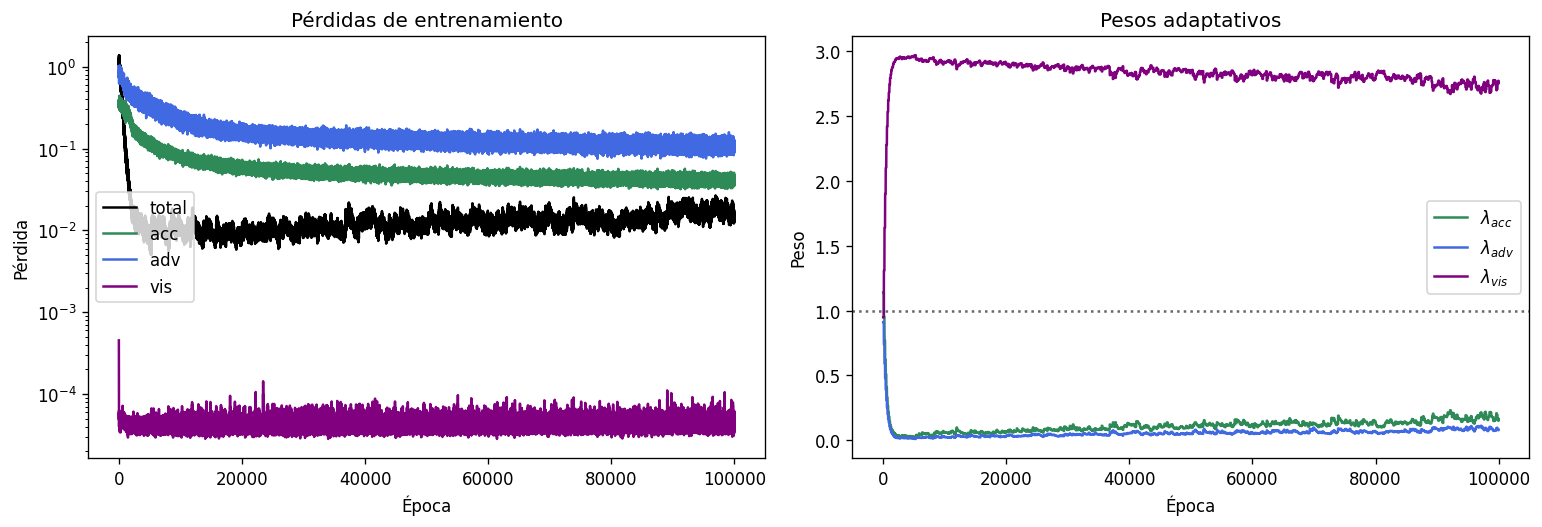

In [95]:
# ============================================================
# Pérdidas y pesos adaptativos de las tres componentes
# ============================================================
checkpoint_last_path = run_dir / "checkpoints" / "checkpoint_last.pth"
if checkpoint_last_path.exists():
    checkpoint_last_for_history = torch.load(checkpoint_last_path, map_location="cpu")
    training_history = checkpoint_last_for_history.get("history", loss_history)
else:
    training_history = loss_history

required_history = ["total_loss", "loss_acc", "loss_adv", "loss_vis"]
missing = [key for key in required_history if key not in training_history]
if missing:
    raise KeyError(f"Faltan historias de pérdida: {missing}")

history_epoch = np.arange(len(training_history["total_loss"]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=120)

for key, label, color in [
    ("total_loss", "total", "black"),
    ("loss_acc", "acc", "seagreen"),
    ("loss_adv", "adv", "royalblue"),
    ("loss_vis", "vis", "purple"),
]:
    values = np.maximum(np.asarray(training_history[key], dtype=float), 1e-16)
    axes[0].semilogy(history_epoch, values, color=color, label=label)
axes[0].set_title("Pérdidas de entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Pérdida")
axes[0].legend()

for key, label, color in [
    ("lambda_acc", r"$\lambda_{acc}$", "seagreen"),
    ("lambda_adv", r"$\lambda_{adv}$", "royalblue"),
    ("lambda_vis", r"$\lambda_{vis}$", "purple"),
]:
    if key in training_history:
        axes[1].plot(history_epoch, training_history[key], color=color, label=label)
axes[1].axhline(1.0, color="0.4", linestyle=":")
axes[1].set_title("Pesos adaptativos")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Peso")
axes[1].legend()

plt.tight_layout()
plt.show()


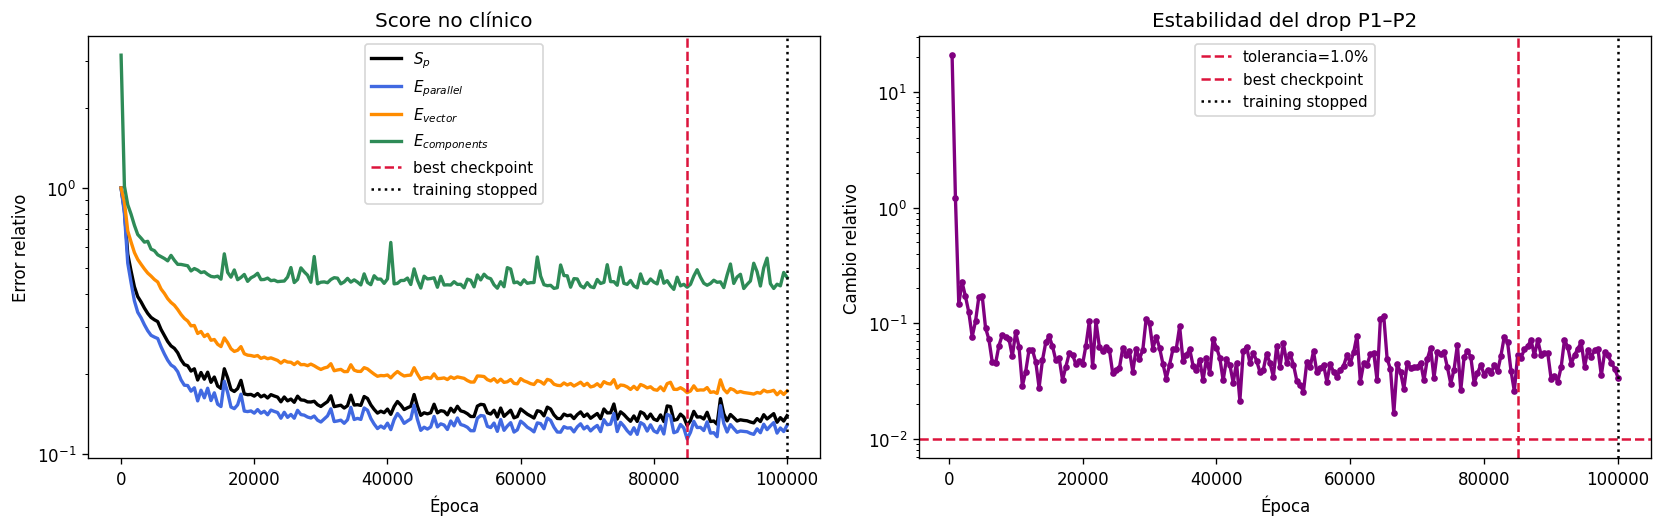

Best checkpoint: 85000
Training stopped: 100000
Pressure gradient score: 0.1276990137050453
Tangential error: 0.11368129801819375


,epoch,pressure_gradient_score,gradient_tangential_relative_mse,gradient_total_vector_relative_mse,gradient_component_balanced_relative_mse,drop_stability_relative,drop_stability_consecutive,best_epoch,improved,early_stop_ready
0,0,0.999386,0.999475,0.999117,3.154505,inf,0,-1,False,False
1,500,0.823004,0.801712,0.886881,1.014812,20.721657,0,-1,False,False
2,1000,0.563156,0.521310,0.688694,0.864486,1.211490,0,-1,False,False
3,1500,0.486560,0.440243,0.625509,0.795861,0.147342,0,-1,False,False
4,2000,0.424783,0.375905,0.571417,0.723279,0.225474,0,-1,False,False
...,...,...,...,...,...,...,...,...,...,...
196,98000,0.141579,0.131001,0.173313,0.418522,0.056152,0,85000,False,False
197,98500,0.131401,0.119618,0.166747,0.434253,0.052891,0,85000,False,False
198,99000,0.136720,0.125050,0.171729,0.428184,0.045501,0,85000,False,False
199,99500,0.132732,0.121257,0.167158,0.480687,0.040517,0,85000,False,False


In [96]:
# ============================================================
# Métricas usadas por el early stopping no clínico
# ============================================================
checkpoint_last_path = run_dir / "checkpoints" / "checkpoint_last.pth"
ckpt_last = (
    torch.load(checkpoint_last_path, map_location="cpu")
    if checkpoint_last_path.exists()
    else None
)
validation_history = (
    ckpt_last.get("validation_history", [])
    if ckpt_last is not None
    else extra_state.get("validation_history", [])
)
best_pressure_iteration = int(
    ckpt_last.get("best_epoch", ckpt.get("epoch", 0))
    if ckpt_last is not None
    else ckpt.get("epoch", 0)
)
stop_pressure_iteration = int(
    ckpt_last.get("epoch", best_pressure_iteration)
    if ckpt_last is not None
    else best_pressure_iteration
)
if len(validation_history) == 0:
    raise ValueError("No hay validation_history disponible.")

validation_df = pd.DataFrame(validation_history).sort_values("epoch").reset_index(drop=True)
required_metrics = [
    "pressure_gradient_score",
    "gradient_tangential_relative_mse",
    "gradient_total_vector_relative_mse",
    "gradient_component_balanced_relative_mse",
    "drop_stability_relative",
]
missing = [key for key in required_metrics if key not in validation_df]
if missing:
    raise KeyError(f"Faltan métricas del criterio no clínico: {missing}")

epochs = validation_df["epoch"].to_numpy(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=120)
for column, label, color in [
    ("pressure_gradient_score", r"$S_p$", "black"),
    ("gradient_tangential_relative_mse", r"$E_{parallel}$", "royalblue"),
    ("gradient_total_vector_relative_mse", r"$E_{vector}$", "darkorange"),
    ("gradient_component_balanced_relative_mse", r"$E_{components}$", "seagreen"),
]:
    axes[0].semilogy(epochs, validation_df[column], lw=2, label=label, color=color)
axes[0].axvline(best_pressure_iteration, ls="--", color="crimson", label="best checkpoint")
axes[0].axvline(stop_pressure_iteration, ls=":", color="black", label="training stopped")
axes[0].set_title("Score no clínico")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Error relativo")
axes[0].legend(fontsize=9)

drop_stability = validation_df["drop_stability_relative"].replace([np.inf, -np.inf], np.nan)
stability_tolerance = float(extra_state.get("drop_stability_tolerance", 1e-2))
axes[1].semilogy(epochs, drop_stability, marker="o", ms=3, lw=2, color="purple")
axes[1].axhline(stability_tolerance, ls="--", color="crimson", label=f"tolerancia={100*stability_tolerance:.1f}%")
axes[1].axvline(best_pressure_iteration, ls="--", color="crimson", label="best checkpoint")
axes[1].axvline(stop_pressure_iteration, ls=":", color="black", label="training stopped")
axes[1].set_title("Estabilidad del drop P1–P2")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Cambio relativo")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

best_row = validation_df.iloc[(validation_df["epoch"] - best_pressure_iteration).abs().argmin()]
print("Best checkpoint:", best_pressure_iteration)
print("Training stopped:", stop_pressure_iteration)
print("Pressure gradient score:", best_row["pressure_gradient_score"])
print("Tangential error:", best_row["gradient_tangential_relative_mse"])

display_columns = [
    "epoch", "pressure_gradient_score",
    "gradient_tangential_relative_mse",
    "gradient_total_vector_relative_mse",
    "gradient_component_balanced_relative_mse",
    "drop_stability_relative", "drop_stability_consecutive",
    "best_epoch", "improved", "early_stop_ready",
]
display(validation_df[display_columns])


# Predicción de presión total y componentes

La red devuelve `[p_acc, p_adv, p_vis]`. La presión total se calcula como la suma de las tres salidas.


In [97]:
Data.shape

(28, 2565, 7)

In [98]:
Data_centerline.shape

(200, 3)

In [99]:
import numpy as np
from scipy.spatial import cKDTree


def densify_curved_cylinder(
    Data,
    Data_centerline,
    factor=3,
    radius_window=8,
    safety_factor=0.95,
    seed=1234,
):
    """
    Aumenta la densidad espacial dentro del tubo curvado definido por
    Data y Data_centerline.

    Conserva los puntos originales y añade puntos nuevos dentro de
    secciones normales a la línea central.

    Parameters
    ----------
    Data : ndarray, shape (Nt, Np, >=4)
        Data[..., 0:3] contiene las coordenadas espaciales.

    Data_centerline : ndarray, shape (Nc, >=3)
        Línea central ordenada del conducto.

    factor : int
        Factor final de densificación. factor=3 transforma 481 en 1443.

    radius_window : int
        Número de puntos vecinos de la centerline usados para estimar
        el radio local.

    safety_factor : float
        Fracción del radio estimado utilizada. Un valor menor que 1
        mantiene los puntos alejados de la frontera.

    seed : int
        Semilla aleatoria.

    Returns
    -------
    xyz_dense : ndarray, shape (factor*Np, 3)
        Coordenadas originales más las coordenadas nuevas.

    radius_profile : ndarray, shape (Nc,)
        Radio estimado a lo largo de la línea central.
    """
    xyz_original = np.asarray(Data[0, :, 0:3], dtype=np.float64)
    centerline = np.asarray(
        Data_centerline[:, 0:3],
        dtype=np.float64,
    )

    n_original = xyz_original.shape[0]
    n_target = factor * n_original
    n_new = n_target - n_original

    if n_new <= 0:
        return xyz_original.copy(), None

    rng = np.random.default_rng(seed)

    # ---------------------------------------------------------
    # 1. Asignar cada punto de Data a la posición más cercana
    #    de la línea central.
    # ---------------------------------------------------------
    centerline_tree = cKDTree(centerline)
    radial_distance, centerline_index = centerline_tree.query(
        xyz_original,
        k=1,
    )

    # ---------------------------------------------------------
    # 2. Estimar el radio local mediante una ventana axial.
    #
    # Se usa el máximo radio observado localmente. El factor de
    # seguridad se aplica posteriormente.
    # ---------------------------------------------------------
    n_center = centerline.shape[0]
    radius_profile = np.zeros(n_center, dtype=np.float64)

    for i in range(n_center):
        mask = np.abs(centerline_index - i) <= radius_window

        if np.any(mask):
            radius_profile[i] = np.max(radial_distance[mask])

    # Completar posibles posiciones sin puntos cercanos.
    valid = radius_profile > 0

    if not np.any(valid):
        raise ValueError(
            "No fue posible estimar el radio del conducto."
        )

    radius_profile = np.interp(
        np.arange(n_center),
        np.flatnonzero(valid),
        radius_profile[valid],
    )

    # Suavizado sencillo del perfil de radio.
    kernel_size = 2 * radius_window + 1
    kernel = np.ones(kernel_size) / kernel_size
    radius_profile = np.convolve(
        np.pad(
            radius_profile,
            radius_window,
            mode="edge",
        ),
        kernel,
        mode="valid",
    )

    radius_profile *= safety_factor

    # ---------------------------------------------------------
    # 3. Tangente local de la línea central.
    # ---------------------------------------------------------
    tangents = np.gradient(centerline, axis=0)

    tangent_norm = np.linalg.norm(
        tangents,
        axis=1,
        keepdims=True,
    )

    tangents /= np.maximum(tangent_norm, 1e-14)

    # ---------------------------------------------------------
    # 4. Elegir posiciones distribuidas a lo largo de la
    #    longitud de arco.
    # ---------------------------------------------------------
    segment_length = np.linalg.norm(
        np.diff(centerline, axis=0),
        axis=1,
    )

    arc_length = np.concatenate([
        [0.0],
        np.cumsum(segment_length),
    ])

    sampled_arc = rng.uniform(
        arc_length[0],
        arc_length[-1],
        size=n_new,
    )

    sampled_arc.sort()

    # Centro, tangente y radio interpolados.
    center_new = np.column_stack([
        np.interp(sampled_arc, arc_length, centerline[:, dim])
        for dim in range(3)
    ])

    tangent_new = np.column_stack([
        np.interp(sampled_arc, arc_length, tangents[:, dim])
        for dim in range(3)
    ])

    tangent_new /= np.maximum(
        np.linalg.norm(tangent_new, axis=1, keepdims=True),
        1e-14,
    )

    radius_new = np.interp(
        sampled_arc,
        arc_length,
        radius_profile,
    )

    # ---------------------------------------------------------
    # 5. Construir dos vectores normales a la tangente.
    # ---------------------------------------------------------
    reference = np.tile(
        np.array([0.0, 0.0, 1.0]),
        (n_new, 1),
    )

    # Si la tangente es casi paralela al eje z, usar el eje y.
    parallel = np.abs(tangent_new[:, 2]) > 0.9
    reference[parallel] = np.array([0.0, 1.0, 0.0])

    normal_1 = np.cross(tangent_new, reference)
    normal_1 /= np.maximum(
        np.linalg.norm(normal_1, axis=1, keepdims=True),
        1e-14,
    )

    normal_2 = np.cross(tangent_new, normal_1)
    normal_2 /= np.maximum(
        np.linalg.norm(normal_2, axis=1, keepdims=True),
        1e-14,
    )

    # ---------------------------------------------------------
    # 6. Muestreo uniforme dentro de cada disco.
    #
    # sqrt(U) produce distribución uniforme en área.
    # ---------------------------------------------------------
    radial_coordinate = radius_new * np.sqrt(
        rng.uniform(0.0, 1.0, size=n_new)
    )

    theta = rng.uniform(
        0.0,
        2.0 * np.pi,
        size=n_new,
    )

    xyz_new = (
        center_new
        + radial_coordinate[:, None]
        * (
            np.cos(theta)[:, None] * normal_1
            + np.sin(theta)[:, None] * normal_2
        )
    )

    xyz_dense = np.concatenate(
        [xyz_original, xyz_new],
        axis=0,
    )

    return xyz_dense, radius_profile

In [100]:
xyz_dense, radius_profile = densify_curved_cylinder(
    Data=Data,
    Data_centerline=Data_centerline,
    factor=30,
    radius_window=8,
    safety_factor=0.95,
    seed=1234,
)

print(Data.shape[1])
# 481

print(xyz_dense.shape)
# (1443, 3)

2565
(76950, 3)


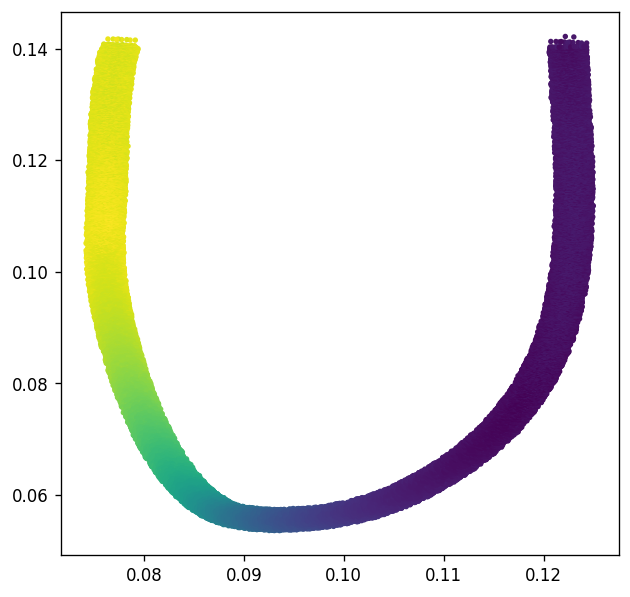

In [101]:
plt.figure(figsize=(6, 6), dpi=120)
plt.scatter(
    xyz_dense[:, 0],
    xyz_dense[:, 1],
    c=xyz_dense[:, 2],
    cmap="viridis",
    s=5,
)

In [102]:
xyz_dense.shape, Data.shape, Data_centerline.shape

((76950, 3), (28, 2565, 7), (200, 3))

In [103]:
import numpy as np

# Shapes esperados:
# xyz_dense.shape = (14430, 3)
# Data.shape      = (25, 481, 7)

Nt = Data.shape[0]
Np = xyz_dense.shape[0]

# Tiempos de los 25 frames.
# Asumo que la cuarta columna de Data es el tiempo
# y que es constante para todos los puntos de cada frame.
time_values = Data[:, 0, 3]  # shape: (25,)

# Repetir las coordenadas espaciales para cada frame
xyz_all = np.broadcast_to(
    xyz_dense[None, :, :],
    (Nt, Np, 3),
).copy()

# Repetir cada tiempo para los 14430 puntos
time_all = np.broadcast_to(
    time_values[:, None, None],
    (Nt, Np, 1),
).copy()

# Concatenar [x, y, z, t]
Data_dense = np.concatenate(
    [xyz_all, time_all],
    axis=2,
)

print("Data_dense.shape:", Data_dense.shape)

Data_dense.shape: (28, 76950, 4)


In [104]:
def predict_pressure_field(model, Data, Data_centerline, dic_adim_norm):
    """Predice p_total, p_acc, p_adv y p_vis en mmHg.

    Orden de las salidas de la red:
        0 -> p_acc
        1 -> p_adv
        2 -> p_vis
    """
    n_t = Data.shape[0]
    n_p = Data.shape[1]
    Nt = n_t
    Np = Data_centerline.shape[0]

    # Usar exactamente los tiempos del dataset, sin reconstruirlos.
    time_values = np.asarray(Data[:, 0, 3], dtype=np.float64)

    mu = np.array([
        float(np.asarray(dic_adim_norm["mu_x"]).squeeze()),
        float(np.asarray(dic_adim_norm["mu_y"]).squeeze()),
        float(np.asarray(dic_adim_norm["mu_z"]).squeeze()),
        float(np.asarray(dic_adim_norm["mu_t"]).squeeze()),
    ], dtype=np.float64)
    sigma = np.array([
        float(np.asarray(dic_adim_norm["sigma_x"]).squeeze()),
        float(np.asarray(dic_adim_norm["sigma_y"]).squeeze()),
        float(np.asarray(dic_adim_norm["sigma_z"]).squeeze()),
        float(np.asarray(dic_adim_norm["sigma_t"]).squeeze()),
    ], dtype=np.float64)
    L_local = float(np.asarray(dic_adim_norm["L"]).squeeze())
    T_local = float(np.asarray(dic_adim_norm["T"]).squeeze())
    p0_local = float(np.asarray(dic_adim_norm["p0"]).squeeze())
    mmhg_scale = p0_local / 133.322

    # --------------------------------------------------------
    # Predicción sobre la línea central
    # --------------------------------------------------------
    xyz = np.broadcast_to(Data_centerline[None, :, :], (Nt, Np, 3))
    time_grid = np.broadcast_to(time_values[:, None, None], (Nt, Np, 1))
    X = np.concatenate([xyz, time_grid], axis=2)
    X_flat = X.reshape(-1, 4)
    X_nd = X_flat.copy()
    X_nd[:, :3] /= L_local
    X_nd[:, 3] /= T_local
    X_norm = (X_nd - mu) / sigma

    with torch.no_grad():
        X_tensor = torch.as_tensor(X_norm, dtype=torch.float64)
        P_components_center = model(
            X_tensor[:, 0:1], X_tensor[:, 1:2],
            X_tensor[:, 2:3], X_tensor[:, 3:4],
        ) * mmhg_scale

    P_pred_acc_center = P_components_center[:, 0:1]
    P_pred_adv_center = P_components_center[:, 1:2]
    P_pred_vis_center = P_components_center[:, 2:3]
    P_pred_total_center = P_components_center.sum(dim=1, keepdim=True)

    p_total_center_np = P_pred_total_center.cpu().numpy().reshape(Nt, Np, 1)
    p_acc_center_np = P_pred_acc_center.cpu().numpy().reshape(Nt, Np, 1)
    p_adv_center_np = P_pred_adv_center.cpu().numpy().reshape(Nt, Np, 1)
    p_vis_center_np = P_pred_vis_center.cpu().numpy().reshape(Nt, Np, 1)
    Data_pred_pres_center = np.concatenate(
        [X, p_total_center_np, p_acc_center_np, p_adv_center_np, p_vis_center_np],
        axis=2,
    )

    # --------------------------------------------------------
    # Predicción total sobre los puntos del dataset
    # --------------------------------------------------------
    X_flat_data = Data[:, :, 0:4].reshape(-1, 4)
    X_nd_data = X_flat_data.copy()
    X_nd_data[:, :3] /= L_local
    X_nd_data[:, 3] /= T_local
    X_norm_data = (X_nd_data - mu) / sigma

    with torch.no_grad():
        X_tensor_data = torch.as_tensor(X_norm_data, dtype=torch.float64)
        P_components_data = model(
            X_tensor_data[:, 0:1], X_tensor_data[:, 1:2],
            X_tensor_data[:, 2:3], X_tensor_data[:, 3:4],
        ) * mmhg_scale
        P_pred_acc_data = P_components_data[:, 0:1]
        P_pred_adv_data = P_components_data[:, 1:2]
        P_pred_vis_data = P_components_data[:, 2:3]
        P_pred_total_data = P_components_data.sum(dim=1, keepdim=True)

    p_total_data_np = P_pred_total_data.cpu().numpy().reshape(n_t, n_p, 1)
    p_acc_data_np = P_pred_acc_data.cpu().numpy().reshape(n_t, n_p, 1)
    p_adv_data_np = P_pred_adv_data.cpu().numpy().reshape(n_t, n_p, 1)
    p_vis_data_np = P_pred_vis_data.cpu().numpy().reshape(n_t, n_p, 1)
    Data_pred_pres = np.concatenate(
        [Data[:, :, 0:4], p_total_data_np, p_acc_data_np, p_adv_data_np, p_vis_data_np], axis=2
    )
    return Data_pred_pres, Data_pred_pres_center

In [105]:
# Data_pred_pres, Data_pred_pres_center = predict_pressure_field(net_pres, Data, Data_centerline, dic_adim)
Data_pred_pres, Data_pred_pres_center = predict_pressure_field(net_pres, Data_dense, Data_centerline, dic_adim)


In [106]:
Data_pred_pres.shape, Data_pred_pres_center.shape

((28, 76950, 8), (28, 200, 8))

In [107]:
Data_centerline.shape

(200, 3)

# Drop total y contribuciones

La suma de las tres curvas debe coincidir numéricamente con el drop total.

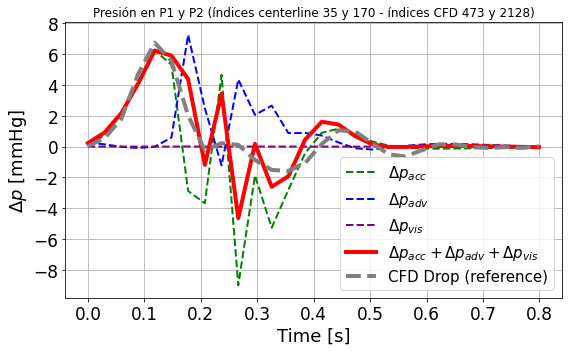

In [108]:
### select points on centerline
idx_p1 = 35
# idx_p2 = 90
# idx_p2 = 138
idx_p2 = 170
#idx_p2 = 190

P1_manual = Data_centerline[idx_p1,:3]
P2_manual = Data_centerline[idx_p2,:3]

P1 = P1_manual.reshape(1, 3)
P2 = P2_manual.reshape(1, 3)

# Presiones predichas en centerline
p1_total = Data_pred_pres_center[:, idx_p1, 4]
p1_acc = Data_pred_pres_center[:, idx_p1, 5]
p1_adv = Data_pred_pres_center[:, idx_p1, 6]
p1_vis = Data_pred_pres_center[:, idx_p1, 7]
p2_total = Data_pred_pres_center[:, idx_p2, 4]
p2_acc = Data_pred_pres_center[:, idx_p2, 5]
p2_adv = Data_pred_pres_center[:, idx_p2, 6]
p2_vis = Data_pred_pres_center[:, idx_p2, 7]

drop_total = p1_total - p2_total
drop_acc = p1_acc - p2_acc
drop_adv = p1_adv - p2_adv
drop_vis = p1_vis - p2_vis

# Presiones CFD 
xyz_ref = Data_pred_cfd[0, :, 0:3]
time_p = Data_pred_cfd[:, 0, 3]

dist2_p1 = np.sum((xyz_ref - P1)**2, axis=1)
dist2_p2 = np.sum((xyz_ref - P2)**2, axis=1)

idx_cfd_p1 = int(np.argmin(dist2_p1))
idx_cfd_p2 = int(np.argmin(dist2_p2))

P1_cfd = xyz_ref[idx_cfd_p1,:]
P2_cfd = xyz_ref[idx_cfd_p2,:]

p1_cfd = Data_pred_cfd[:, idx_cfd_p1, -1]
p2_cfd = Data_pred_cfd[:, idx_cfd_p2, -1]
drop_cfd = p1_cfd - p2_cfd


plt.figure(figsize=(8,5))

plt.plot(
    time_p,
    drop_acc,
    linewidth=2,
    color='green',
    linestyle='--',
    label=r'$\Delta p_{acc}$'
)

plt.plot(
    time_p,
    drop_adv,
    linewidth=2,
    color='blue',
    linestyle='--',
    label=r'$\Delta p_{adv}$'
)

plt.plot(
    time_p,
    drop_vis,
    linewidth=2,
    color='purple',
    linestyle='--',
    label=r'$\Delta p_{vis}$'
)

plt.plot(
    time_p,
    drop_total,
    linewidth=4,
    color='red',
    label=r'$\Delta p_{acc}+\Delta p_{adv}+\Delta p_{vis}$'
)

plt.plot(
    time_p,
    drop_cfd,
    linewidth=4,
    color='grey',
    linestyle='--',
    label='CFD Drop (reference)'
)

plt.xlabel("Time [s]", fontsize=18)
plt.ylabel(r"$\Delta p$ [mmHg]", fontsize=18)
plt.title(f"Presión en P1 y P2 (índices centerline {idx_p1} y {idx_p2} - índices CFD {idx_cfd_p1} y {idx_cfd_p2})")
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.grid(True)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [109]:
drop_vis.shape

(28,)

In [110]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact
import ipywidgets as widgets

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# Usa Data_pred_pres para hacer un gráfico 3D
def interactive_pressure_field_3d(
    Data_pred,
    Data_seg,
    Data_centerline,
    P1_centerline,
    P2_centerline,
    P1_cfd,
    P2_cfd,
    percentile_min=1,
    percentile_max=99,
    default_frame=0,
    default_azim=60,
    default_elev=20,
    point_size_pred=8,
    point_size_seg=2,
    point_size_centerline=20,
    show_segmentation=True,
    show_pressure=True,
):
    """
    Visualización 3D interactiva del campo de presión.

    Data_pred: shape (Nt, Np_data, 5)
        [x, y, z, t, p_total]

    P1_centerline: shape (1, 3) o (3,)
        Coordenadas de P1 en la centerline.

    P2_centerline: shape (1, 3) o (3,)
        Coordenadas de P2 en la centerline.

    P1_cfd: shape (3,)
        Coordenadas de P1 en la malla CFD.

    P2_cfd: shape (3,)
        Coordenadas de P2 en la malla CFD.

    Data_seg: shape (Nt, Np_seg, >=3) o (Np_seg, >=3)
        Geometría/anatomía en gris.

    Data_centerline: shape (Np_center, >=3)
        Línea central.

    show_segmentation:
        Si es True, muestra la segmentación.

    show_pressure:
        Si es True, muestra el campo de presión y la barra de color.
    """

    Data_pred = np.asarray(Data_pred, dtype=np.float64)
    Data_seg = np.asarray(Data_seg, dtype=np.float64)
    Data_centerline = np.asarray(
        Data_centerline,
        dtype=np.float64,
    )

    P1_centerline = np.asarray(
        P1_centerline,
        dtype=np.float64,
    ).reshape(-1)

    P2_centerline = np.asarray(
        P2_centerline,
        dtype=np.float64,
    ).reshape(-1)

    P1_cfd = np.asarray(
        P1_cfd,
        dtype=np.float64,
    ).reshape(-1)

    P2_cfd = np.asarray(
        P2_cfd,
        dtype=np.float64,
    ).reshape(-1)

    if Data_pred.ndim != 3 or Data_pred.shape[2] < 5:
        raise ValueError(
            "Data_pred debe tener shape (Nt, Np_data, >=5) "
            "con [x, y, z, t, p_total]."
        )

    if Data_centerline.ndim != 2 or Data_centerline.shape[1] < 3:
        raise ValueError(
            "Data_centerline debe tener shape (Np_center, >=3)."
        )

    Nt = Data_pred.shape[0]

    if not (0 <= default_frame < Nt):
        default_frame = 0

    # ========================================================
    # Límites globales para la presión
    # ========================================================

    p_all_aux = Data_pred[:, :, 4]
    p_all = Data_pred[:, :, 4]

    pmin = np.nanpercentile(
        p_all,
        percentile_min,
    )

    pmax = np.nanpercentile(
        p_all,
        percentile_max,
    )

    if (
        not np.isfinite(pmin)
        or not np.isfinite(pmax)
        or pmin >= pmax
    ):
        pmin = np.nanmin(p_all)
        pmax = np.nanmax(p_all)

    # ========================================================
    # Obtener segmentación del frame
    # ========================================================

    def _get_seg_frame(frame):

        if Data_seg.ndim == 3:
            frame = min(
                max(frame, 0),
                Data_seg.shape[0] - 1,
            )

            return Data_seg[
                frame,
                :,
                :3,
            ]

        if Data_seg.ndim == 2:
            return Data_seg[:, :3]

        raise ValueError(
            "Data_seg debe tener shape "
            "(Nt, Np_seg, >=3) o (Np_seg, >=3)."
        )

    # ========================================================
    # Interactividad
    # ========================================================

    @interact(
        frame=widgets.IntSlider(
            value=default_frame,
            min=0,
            max=Nt - 1,
            step=1,
            description="time step",
            continuous_update=False,
        ),
        azim=widgets.IntSlider(
            value=default_azim,
            min=-180,
            max=180,
            step=1,
            description="azimuth",
            continuous_update=False,
        ),
        elev=widgets.IntSlider(
            value=default_elev,
            min=-90,
            max=90,
            step=1,
            description="elevation",
            continuous_update=False,
        ),
    )
    def _plot(frame, azim, elev):

        pred_frame = Data_pred[frame]

        xyz_pred = pred_frame[:, :3]
        p_pred = pred_frame[:, 4]

        seg_xyz = _get_seg_frame(frame)
        center_xyz = Data_centerline[:, :3]

        fig = plt.figure(
            figsize=(10, 8),
            facecolor="white",
        )

        ax = fig.add_subplot(
            111,
            projection="3d",
        )

        # ====================================================
        # Segmentación anatómica
        # ====================================================

        if show_segmentation:
            ax.scatter(
                seg_xyz[:, 0],
                seg_xyz[:, 1],
                seg_xyz[:, 2],
                c="lightgrey",
                s=point_size_seg,
                alpha=0.1,
                depthshade=False,
            )

        # ====================================================
        # Campo de presión
        # ====================================================

        sc = None

        if show_pressure:
            sc = ax.scatter(
                xyz_pred[:, 0],
                xyz_pred[:, 1],
                xyz_pred[:, 2],
                c=p_pred,
                cmap="jet",
                s=point_size_pred,
                alpha=0.4,
                vmin=pmin,
                vmax=pmax,
                depthshade=False,
            )

        # ====================================================
        # Línea central
        # ====================================================

        ax.plot(
            center_xyz[:, 0],
            center_xyz[:, 1],
            center_xyz[:, 2],
            color="black",
            linewidth=2.0,
            alpha=0.9,
        )

        # ====================================================
        # Puntos en centerline
        # ====================================================

        ax.scatter(
            P1_centerline[0],
            P1_centerline[1],
            P1_centerline[2],
            c="red",
            s=150,
            linewidths=4,
            marker="x",
        )

        ax.scatter(
            P2_centerline[0],
            P2_centerline[1],
            P2_centerline[2],
            c="blue",
            s=150,
            linewidths=4,
            marker="x",
        )

        # ====================================================
        # Puntos CFD
        # ====================================================

        ax.scatter(
            P1_cfd[0],
            P1_cfd[1],
            P1_cfd[2],
            c="red",
            s=50,
            linewidths=4,
            marker="o",
        )

        ax.scatter(
            P2_cfd[0],
            P2_cfd[1],
            P2_cfd[2],
            c="blue",
            s=50,
            linewidths=4,
            marker="o",
        )

        # ====================================================
        # Barra de color compacta
        # ====================================================

        if show_pressure and sc is not None:

            cax = inset_axes(
                ax,
                width="3.5%",
                height="48%",
                loc="center right",
                bbox_to_anchor=(
                    0.17,
                    0.0,
                    1.0,
                    1.0,
                ),
                bbox_transform=ax.transAxes,
                borderpad=0,
            )

            cbar = fig.colorbar(
                sc,
                cax=cax,
                orientation="vertical",
            )

            # Mostrar solo los extremos
            cbar.set_ticks([
                pmin,
                pmax,
            ])

            cbar.set_ticklabels([
                f"{pmin:.1f}",
                f"{pmax:.1f}",
            ])

            cbar.ax.tick_params(
                labelsize=15,
                width=0,
                length=0,
                pad=4,
            )

            cbar.set_label(
                r"$\Delta P$ [mmHg]",
                fontsize=15,
                fontweight="bold",
                rotation=270,
                labelpad=24,
            )

            cbar.outline.set_linewidth(1.5)
            cbar.outline.set_edgecolor("black")

        # ====================================================
        # Vista y formato
        # ====================================================

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

        time_value = pred_frame[0, 3]

        ax.set_title(
            f"Campo de presión 3D | "
            f"frame={frame} | "
            f"t={time_value:.4f} s"
        )

        ax.view_init(
            elev=elev,
            azim=azim,
        )

        ax.set_box_aspect((1, 1, 1))

        # Sin leyenda
        ax.set_axis_off()

        fig.subplots_adjust(
            left=0.00,
            right=0.87,
            bottom=0.00,
            top=0.95,
        )

        plt.show()

In [111]:
interactive_pressure_field_3d(
    Data_pred=Data_pred_pres,
    Data_seg=Data_seg,
    Data_centerline=Data_centerline,
    P1_centerline=P1,
    P2_centerline=P2,
    P1_cfd=P1_cfd,
    P2_cfd=P2_cfd,
    percentile_min=1,
    percentile_max=99,
    default_frame=6,
    default_azim=-90,
    default_elev=-90,
    point_size_pred=8,
    point_size_seg=2,
    point_size_centerline=12,
    show_segmentation=True,
    show_pressure=False,
)

interactive(children=(IntSlider(value=6, continuous_update=False, description='time step', max=27), IntSlider(…

In [112]:
# ============================================================
# Métricas por semilla para análisis global (modelo vs CFD)
# ============================================================

eps = 1e-12

# Señales base de comparación (sin alineación temporal)
time_aligned = np.asarray(time_p, dtype=float).copy()
drop_model_selected = np.asarray(drop_total, dtype=float).copy()
drop_model_acc_selected = np.asarray(drop_acc, dtype=float).copy()
drop_model_adv_selected = np.asarray(drop_adv, dtype=float).copy()
drop_model_vis_selected = np.asarray(drop_vis, dtype=float).copy()
drop_reference_aligned = np.asarray(drop_cfd, dtype=float).copy()

if drop_model_selected.shape != drop_reference_aligned.shape:
    raise ValueError(
        f"Shape mismatch modelo/CFD: {drop_model_selected.shape} vs {drop_reference_aligned.shape}"
    )

error = drop_model_selected - drop_reference_aligned
rmse = float(np.sqrt(np.mean(error**2)))
mae = float(np.mean(np.abs(error)))
bias = float(np.mean(error))

ref_range = float(np.max(drop_reference_aligned) - np.min(drop_reference_aligned))
nrmse_ref_percent = float(100.0 * rmse / max(ref_range, eps))

ref_mean = float(np.mean(drop_reference_aligned))
ss_tot = float(np.sum((drop_reference_aligned - ref_mean) ** 2))
ss_res = float(np.sum(error**2))
r2 = float(1.0 - ss_res / ss_tot) if ss_tot > eps else float("nan")

peak_model = float(np.max(drop_model_selected))
peak_ref = float(np.max(drop_reference_aligned))
peak_error_mmHg = float(peak_model - peak_ref)
peak_error_percent = float(100.0 * abs(peak_error_mmHg) / max(abs(peak_ref), eps))

amp_model = float(np.max(drop_model_selected) - np.min(drop_model_selected))
amp_ref = float(np.max(drop_reference_aligned) - np.min(drop_reference_aligned))
amp_error_percent = float(100.0 * abs(amp_model - amp_ref) / max(abs(amp_ref), eps))

corr = float(np.corrcoef(drop_model_selected, drop_reference_aligned)[0, 1])

metrics_seed_dict = {
    "subject": "cfd_9mm",
    "pressure_run_name": pressure_run_name,
    "checkpoint_epoch": int(ckpt.get("epoch", -1)),
    "idx_p1_centerline": int(idx_p1),
    "idx_p2_centerline": int(idx_p2),
    "idx_p1_cfd": int(idx_cfd_p1),
    "idx_p2_cfd": int(idx_cfd_p2),
    "rmse_mmHg": rmse,
    "mae_mmHg": mae,
    "bias_mmHg": bias,
    "nrmse_ref_percent": nrmse_ref_percent,
    "r2": r2,
    "pearson_r": corr,
    "peak_model_mmHg": peak_model,
    "peak_ref_mmHg": peak_ref,
    "peak_error_mmHg": peak_error_mmHg,
    "peak_error_percent": peak_error_percent,
    "amplitude_model_mmHg": amp_model,
    "amplitude_ref_mmHg": amp_ref,
    "amplitude_error_percent": amp_error_percent,
}

metrics_seed_df = pd.DataFrame([metrics_seed_dict])
display(metrics_seed_df)

,subject,pressure_run_name,checkpoint_epoch,idx_p1_centerline,idx_p2_centerline,idx_p1_cfd,idx_p2_cfd,rmse_mmHg,mae_mmHg,bias_mmHg,nrmse_ref_percent,r2,pearson_r,peak_model_mmHg,peak_ref_mmHg,peak_error_mmHg,peak_error_percent,amplitude_model_mmHg,amplitude_ref_mmHg,amplitude_error_percent
0,cfd_9mm,seed_005_20260816_163352,85000,35,170,473,2128,1.312899,0.778444,0.139097,15.763492,0.539239,0.82499,6.237762,6.746107,-0.508345,7.535389,10.885156,8.328732,30.694026


In [113]:
# ============================================================
# Exportar curvas y métricas de la semilla actual
# ============================================================

from pathlib import Path
import json

# Carpeta de salida
export_dir = run_dir / "exports"
export_dir.mkdir(parents=True, exist_ok=True)

# Nombre base opcional para identificar el experimento
export_tag = f"{pressure_run_name}_cfd_idxP1_{idx_p1}_idxP2_{idx_p2}"

# 1) Curvas en formato tabular (CSV)
curves_df = pd.DataFrame({
    "time_s": time_aligned,
    "drop_model_total_mmHg": drop_model_selected,
    "drop_model_acc_mmHg": drop_model_acc_selected,
    "drop_model_adv_mmHg": drop_model_adv_selected,
    "drop_model_vis_mmHg": drop_model_vis_selected,
    "drop_cfd_reference_mmHg": drop_reference_aligned,
})

curves_csv_path = export_dir / f"pressure_drop_curves_{export_tag}.csv"
curves_df.to_csv(curves_csv_path, index=False)

# 2) Curvas en binario (NPZ) para reusar sin perder precisión
curves_npz_path = export_dir / f"pressure_drop_curves_{export_tag}.npz"
np.savez(
    curves_npz_path,
    time_s=time_aligned,
    drop_model_total_mmHg=drop_model_selected,
    drop_model_acc_mmHg=drop_model_acc_selected,
    drop_model_adv_mmHg=drop_model_adv_selected,
    drop_model_vis_mmHg=drop_model_vis_selected,
    drop_cfd_reference_mmHg=drop_reference_aligned,
    idx_p1_centerline=idx_p1,
    idx_p2_centerline=idx_p2,
    idx_p1_cfd=idx_cfd_p1,
    idx_p2_cfd=idx_cfd_p2,
)

# 3) Métricas de la semilla (JSON + CSV individual)
metrics_json_path = export_dir / f"pressure_drop_metrics_{export_tag}.json"
with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_seed_dict, f, indent=2)

metrics_csv_path = export_dir / f"pressure_drop_metrics_{export_tag}.csv"
metrics_seed_df.to_csv(metrics_csv_path, index=False)

# 4) CSV acumulado para análisis global multi-semilla
global_metrics_csv_path = export_dir / "pressure_drop_metrics_all_seeds.csv"
if global_metrics_csv_path.exists():
    global_metrics_df = pd.read_csv(global_metrics_csv_path)
    global_metrics_df = global_metrics_df[global_metrics_df["pressure_run_name"] != pressure_run_name]
    global_metrics_df = pd.concat([global_metrics_df, metrics_seed_df], ignore_index=True)
else:
    global_metrics_df = metrics_seed_df.copy()

global_metrics_df = global_metrics_df.sort_values("pressure_run_name").reset_index(drop=True)
global_metrics_df.to_csv(global_metrics_csv_path, index=False)

print("Guardado completado:")
print(" -", curves_csv_path)
print(" -", curves_npz_path)
print(" -", metrics_json_path)
print(" -", metrics_csv_path)
print(" -", global_metrics_csv_path)

Guardado completado:
 - /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results/seed_005_20260816_163352/exports/pressure_drop_curves_seed_005_20260816_163352_cfd_idxP1_35_idxP2_170.csv
 - /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results/seed_005_20260816_163352/exports/pressure_drop_curves_seed_005_20260816_163352_cfd_idxP1_35_idxP2_170.npz
 - /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results/seed_005_20260816_163352/exports/pressure_drop_metrics_seed_005_20260816_163352_cfd_idxP1_35_idxP2_170.json
 - /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results/seed_005_20260816_163352/exports/pressure_drop_metrics_seed_005_20260816_163352_cfd_idxP1_35_idxP2_170.csv
 - /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/results/seed_005_20260816_163352/exports/pressure_drop_metrics_all_seeds.csv


## Exportación a ParaView de presión predicha

Esta celda exporta `Data_pred_pres` como serie temporal para ParaView con:

- coordenadas espaciales `x, y, z`;
- tiempo por frame;
- `drop_total_pred` en la columna índice 4.

Salida principal:

- `pressure_pred_drop_total.pvd` (para abrir directamente en ParaView).

In [24]:
from pathlib import Path
import numpy as np


def _write_polydata_vtk(file_path, points, scalars, title="pressure_pred"):
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"points must have shape (N, 3), got {points.shape}")

    n_points = points.shape[0]
    path = Path(file_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    lines.append("# vtk DataFile Version 3.0")
    lines.append(title)
    lines.append("ASCII")
    lines.append("DATASET POLYDATA")
    lines.append(f"POINTS {n_points} float")

    for x, y, z in points:
        lines.append(f"{x:.9e} {y:.9e} {z:.9e}")

    lines.append(f"VERTICES {n_points} {2 * n_points}")
    for i in range(n_points):
        lines.append(f"1 {i}")

    lines.append(f"POINT_DATA {n_points}")

    for name, values in scalars.items():
        values = np.asarray(values, dtype=float).reshape(-1)
        if values.shape[0] != n_points:
            raise ValueError(
                f"Scalar '{name}' length mismatch: {values.shape[0]} != {n_points}"
            )
        lines.append(f"SCALARS {name} float 1")
        lines.append("LOOKUP_TABLE default")
        for v in values:
            lines.append(f"{v:.9e}")

    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def _write_polyline_vtk(file_path, points, title="centerline"):
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"centerline points must have shape (N, 3), got {points.shape}")

    n_points = points.shape[0]
    if n_points < 2:
        raise ValueError("centerline must contain at least 2 points")

    path = Path(file_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    lines.append("# vtk DataFile Version 3.0")
    lines.append(title)
    lines.append("ASCII")
    lines.append("DATASET POLYDATA")
    lines.append(f"POINTS {n_points} float")

    for x, y, z in points:
        lines.append(f"{x:.9e} {y:.9e} {z:.9e}")

    lines.append(f"LINES 1 {n_points + 1}")
    polyline_idx = " ".join(str(i) for i in range(n_points))
    lines.append(f"{n_points} {polyline_idx}")

    lines.append(f"POINT_DATA {n_points}")
    lines.append("SCALARS centerline_id float 1")
    lines.append("LOOKUP_TABLE default")
    for _ in range(n_points):
        lines.append("1.0")

    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def _as_xyz_point(point_like, name):
    point = np.asarray(point_like, dtype=float)
    if point.ndim == 2 and point.shape[0] == 1 and point.shape[1] >= 3:
        return point[0, :3]
    if point.ndim == 1 and point.shape[0] >= 3:
        return point[:3]
    raise ValueError(f"{name} must be shape (3,) or (1, 3+), got {point.shape}")


def _write_pvd(pvd_path, rel_files, time_values):
    pvd_path = Path(pvd_path)
    xml = [
        "<?xml version=\"1.0\"?>",
        "<VTKFile type=\"Collection\" version=\"0.1\" byte_order=\"LittleEndian\">",
        "  <Collection>",
    ]

    for t, rel_file in zip(time_values, rel_files):
        xml.append(
            f'    <DataSet timestep="{float(t):.9g}" group="" part="0" file="{rel_file}"/>'
        )

    xml.extend(["  </Collection>", "</VTKFile>"])
    pvd_path.write_text("\n".join(xml) + "\n", encoding="utf-8")


def export_pressure_drop_total_paraview(Data_pred_pres, Data_centerline, P1, P2, output_dir):
    data = np.asarray(Data_pred_pres, dtype=float)
    if data.ndim != 3 or data.shape[2] < 5:
        raise ValueError(
            "Data_pred_pres must have shape (Nt, Np, >=5) with drop_total in column index 4."
        )

    centerline = np.asarray(Data_centerline, dtype=float)
    if centerline.ndim != 2 or centerline.shape[1] < 3:
        raise ValueError(
            "Data_centerline must have shape (Nc, >=3) with coordinates in columns 0:3."
        )

    p1 = _as_xyz_point(P1, "P1")
    p2 = _as_xyz_point(P2, "P2")

    nt, np_points, _ = data.shape
    out_dir = Path(output_dir)
    series_dir = out_dir / "pressure_pred_drop_total"
    series_dir.mkdir(parents=True, exist_ok=True)

    vtk_files_rel = []
    time_values = []

    for frame in range(nt):
        frame_data = data[frame]
        xyz = frame_data[:, :3]
        time_value = float(frame_data[0, 3])
        drop_total_pred = frame_data[:, 4]

        vtk_name = f"pressure_pred_drop_total_{frame:04d}.vtk"
        _write_polydata_vtk(
            file_path=series_dir / vtk_name,
            points=xyz,
            scalars={
                "time": np.full(np_points, time_value, dtype=float),
                "drop_total_pred": drop_total_pred,
            },
            title=f"pressure_pred_drop_total frame {frame}",
        )

        vtk_files_rel.append(f"pressure_pred_drop_total/{vtk_name}")
        time_values.append(time_value)

    pvd_path = out_dir / "pressure_pred_drop_total.pvd"
    _write_pvd(pvd_path, vtk_files_rel, time_values)

    centerline_path = out_dir / "centerline.vtk"
    _write_polyline_vtk(
        file_path=centerline_path,
        points=centerline[:, :3],
        title="centerline",
    )

    p1p2_path = out_dir / "P1_P2_points.vtk"
    p1p2_points = np.vstack([p1, p2])
    _write_polydata_vtk(
        file_path=p1p2_path,
        points=p1p2_points,
        scalars={
            "point_id": np.array([1.0, 2.0], dtype=float),
            "is_P1": np.array([1.0, 0.0], dtype=float),
            "is_P2": np.array([0.0, 1.0], dtype=float),
        },
        title="P1 and P2 points",
    )

    print("Export completed:")
    print(f"  {pvd_path}")
    print(f"  {centerline_path}")
    print(f"  {p1p2_path}")
    print(f"  Frames: {nt}")
    print(f"  Points/frame: {np_points}")
    print(f"  Centerline points: {centerline.shape[0]}")


pressure_export_dir = experiment_dir / "pressure_train" / "paraview_exports"
export_pressure_drop_total_paraview(
    Data_pred_pres=Data_pred_pres,
    Data_centerline=Data_centerline,
    P1=P1,
    P2=P2,
    output_dir=pressure_export_dir,
)


Export completed:
  /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/paraview_exports/pressure_pred_drop_total.pvd
  /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/paraview_exports/centerline.vtk
  /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/13mm_CFD/pressure_train/paraview_exports/P1_P2_points.vtk
  Frames: 28
  Points/frame: 76950
  Centerline points: 200


In [25]:
Data_pred_pres.shape

(28, 76950, 8)